In [ ]:
from google.colab import drive

# 1. Mount the root of your Google Drive
drive.mount('/content/drive')

# 2. Define your specific project path for later use
path = '/content/drive/MyDrive/maestro-v3.0.0-midi'

# Now you can list files or load data from that path
import os
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['maestro-v3.0.0']


In [ ]:
import glob

midi_files = glob.glob(
    '/content/drive/MyDrive/maestro-v3.0.0-midi/**/*.midi',
    recursive=True
)

print("Total MIDI Files:", len(midi_files))

Total MIDI Files: 1276


In [ ]:
!pip install pretty_midi
!pip install pypianoroll
!pip install tqdm

In [ ]:
import os
import glob
import numpy as np
import pretty_midi
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm
import tensorflow as tf

from tensorflow import keras
from keras import layers
from keras.models import Model


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
midi_files = glob.glob(
    '/content/drive/MyDrive/maestro-v3.0.0-midi/**/*.midi',
    recursive=True
)

print("Total MIDI Files:", len(midi_files))

Total MIDI Files: 1276


In [ ]:
# MIDI → piano roll
# normalize timing
# fixed sequence windows

In [ ]:
SEQ_LEN = 64
FS = 16

all_sequences = []

for file in tqdm(midi_files[:300]):

    try:
        midi = pretty_midi.PrettyMIDI(file)

        piano_roll = midi.get_piano_roll(fs=FS)

        piano_roll = (piano_roll > 0).astype(np.float32)

        piano_roll = piano_roll.T

        for i in range(0, len(piano_roll) - SEQ_LEN, SEQ_LEN):

            seq = piano_roll[i:i+SEQ_LEN]

            if seq.shape == (SEQ_LEN, 128):
                all_sequences.append(seq)

    except:
        continue

X = np.array(all_sequences)

print("Dataset Shape:", X.shape)

100%|██████████| 300/300 [01:32<00:00,  3.25it/s]


Dataset Shape: (45549, 64, 128)


In [ ]:
#SAVE DATASET
np.save('/content/music_data.npy', X)

In [ ]:
#BUILD LSTM AUTOENCODER
from tensorflow import keras
from keras.models import Model
from keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed

SEQ_LEN = 64
FEATURES = 128
LATENT_DIM = 128

inputs = Input(shape=(SEQ_LEN, FEATURES))

# Encoder
encoded = LSTM(256)(inputs)

latent = Dense(
    LATENT_DIM,
    activation='relu'
)(encoded)

# Decoder
decoded = RepeatVector(SEQ_LEN)(latent)

decoded = LSTM(
    256,
    return_sequences=True
)(decoded)

outputs = TimeDistributed(
    Dense(FEATURES, activation='sigmoid')
)(decoded)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 64, 128)        │        32,896 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 854,272 (3.26 MB)

 Trainable params: 854,272 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#TRAIN AUTOENCODER
history = autoencoder.fit(
    X,
    X,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.0131 - loss: 0.1265 - val_accuracy: 0.0145 - val_loss: 0.1275
Epoch 2/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.0134 - loss: 0.1233 - val_accuracy: 0.0321 - val_loss: 0.1277
Epoch 3/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.0212 - loss: 0.1113 - val_accuracy: 0.0374 - val_loss: 0.0998
Epoch 4/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.0690 - loss: 0.0843 - val_accuracy: 0.0913 - val_loss: 0.0808
Epoch 5/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.1114 - loss: 0.0736 - val_accuracy: 0.1242 - val_loss: 0.0760
Epoch 6/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.1405 - loss: 0.0685 - val_accuracy: 0.1471 - val_loss: 0.0712
Epoch 7/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.1506 - loss: 0.0648 - val_accuracy: 0.1564 - val_loss: 0.0685
Epoch 8/30
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.1556 -

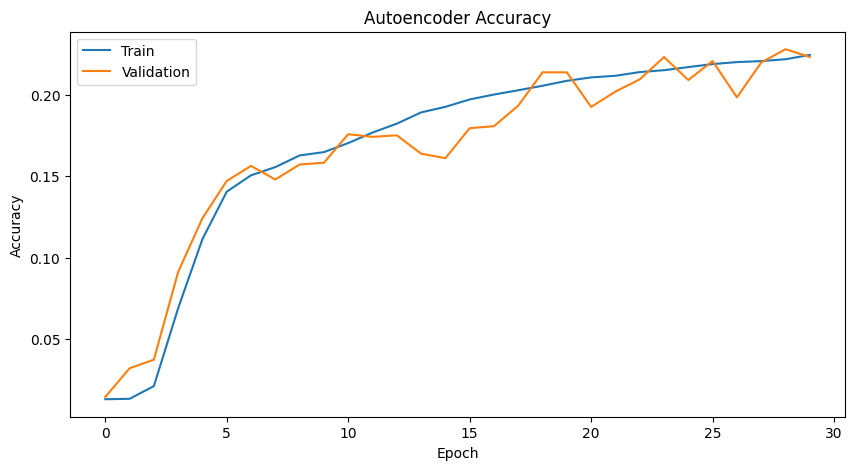

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Autoencoder Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

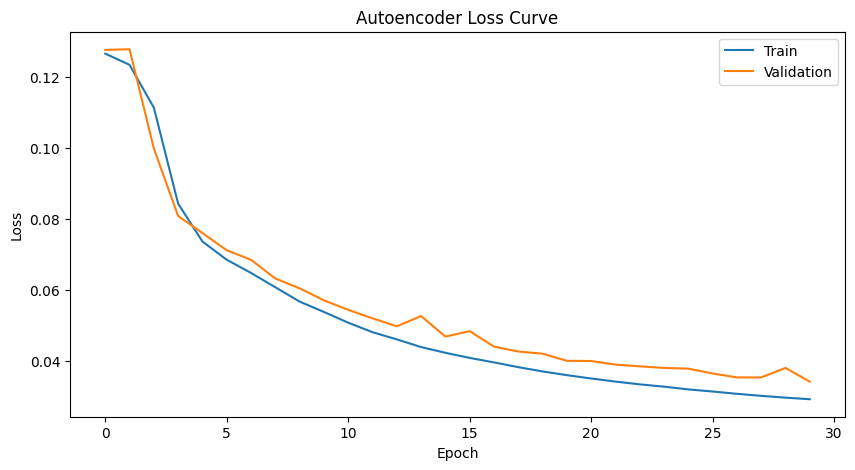

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Autoencoder Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

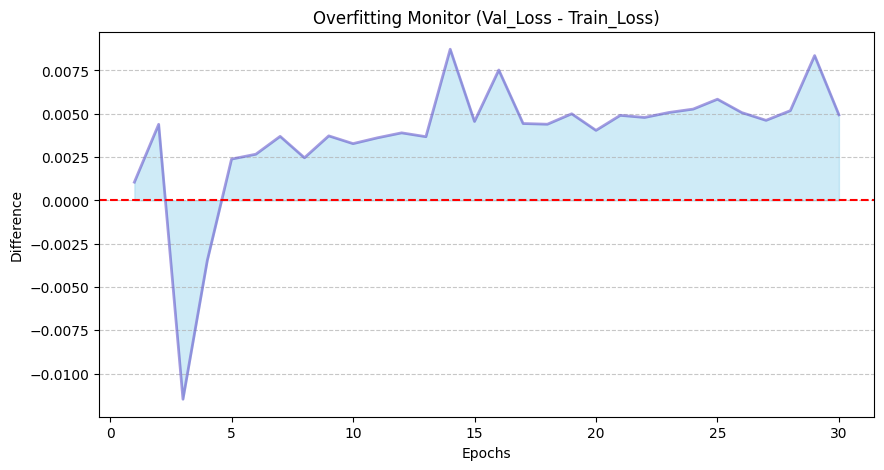

In [ ]:
import matplotlib.pyplot as plt


loss = history.history['loss']
val_loss = history.history['val_loss']
gap = [v - t for v, t in zip(val_loss, loss)]

plt.figure(figsize=(10, 5))
plt.fill_between(range(1, 31), gap, color="skyblue", alpha=0.4)
plt.plot(range(1, 31), gap, color="Slateblue", alpha=0.6, linewidth=2)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Overfitting Monitor (Val_Loss - Train_Loss)')
plt.xlabel('Epochs')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

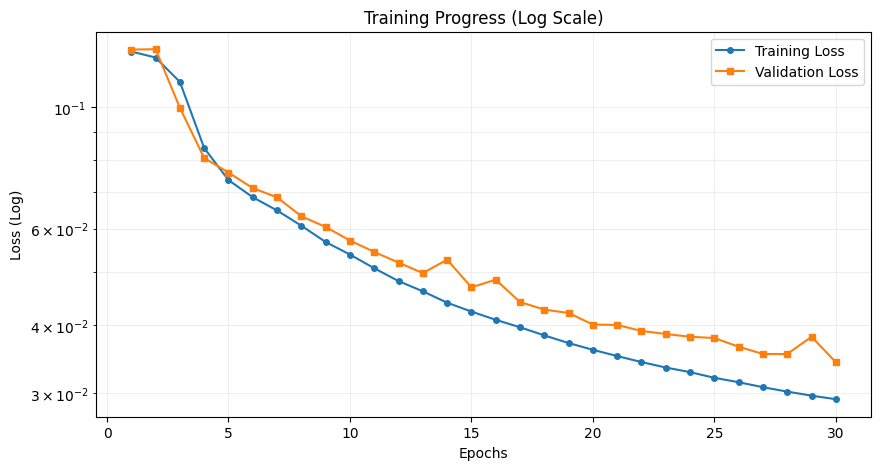

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), loss, label='Training Loss', marker='o', markersize=4)
plt.plot(range(1, 31), val_loss, label='Validation Loss', marker='s', markersize=4)
plt.yscale('log') # This is the magic line
plt.title('Training Progress (Log Scale)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [ ]:
#GENERATE MUSIC USING AUTOENCODER
sample = X[0:1]

generated = autoencoder.predict(sample)[0]

generated = (generated > 0.5).astype(int)

print(generated.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
(64, 128)


In [ ]:
#EXPORT GENERATED MIDI
pm = pretty_midi.PrettyMIDI()

instrument = pretty_midi.Instrument(program=0)

for t in range(generated.shape[0]):

    for pitch in range(128):

        if generated[t, pitch] == 1:

            note = pretty_midi.Note(
                velocity=100,
                pitch=pitch,
                start=t * 0.25,
                end=(t + 1) * 0.25
            )

            instrument.notes.append(note)

pm.instruments.append(instrument)

pm.write('/content/generated_ae.mid')

print("AE MIDI Saved")

AE MIDI Saved


In [ ]:
from google.colab import files

# 1.  download for the file you just created
files.download('/content/generated_ae.mid')

print(f"Total notes in MIDI: {len(instrument.notes)}")

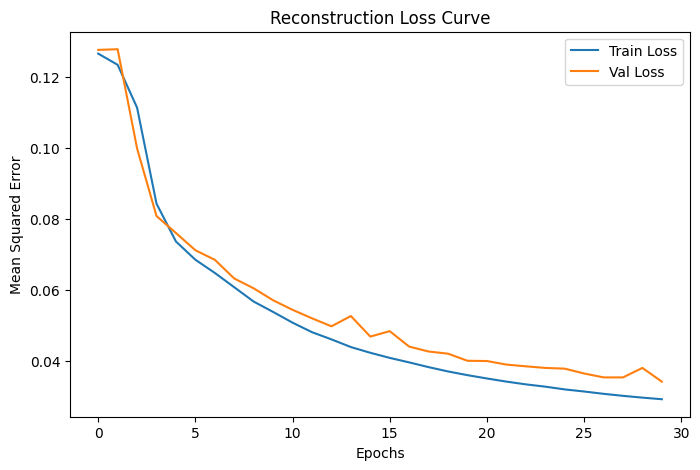

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
Saved: /content/generated_sample_1.mid
Saved: /content/generated_sample_2.mid
Saved: /content/generated_sample_3.mid
Saved: /content/generated_sample_4.mid
Saved: /content/generated_sample_5.mid


In [ ]:
import matplotlib.pyplot as plt

# --- A. Visualize the Loss Curve ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Reconstruction Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

# --- B. Generate 5 Samples ---
reconstructions = autoencoder.predict(X[:5])

for i in range(5):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    # Using a threshold of 0.5 for the probability mask
    gen_sample = reconstructions[i]

    for t in range(gen_sample.shape[0]):
        for pitch in range(128):
            if gen_sample[t, pitch] > 0.5:
                note = pretty_midi.Note(
                    velocity=100, pitch=pitch,
                    start=t * 0.25, end=(t + 1) * 0.25
                )
                instrument.notes.append(note)

    pm.instruments.append(instrument)
    filename = f'/content/generated_sample_{i+1}.mid'
    pm.write(filename)
    print(f"Saved: {filename}")